In [1]:
import json, os, time
import numpy as np
import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cpu")   
print("torch", torch.__version__, "| pennylane", qml.__version__, "| device:", DEVICE)

QUBIT_LIST  = [int(v) for v in os.environ.get("QAPINN_QUBITS", "3,4,5").split(",")]
N_LAYERS    = int(os.environ.get("QAPINN_LAYERS", 8))      
SWEEP_EPOCHS = int(os.environ.get("QAPINN_EPOCHS", 900))   # Adam iters per config
N_DATA_Q  = int(os.environ.get("QAPINN_NDATA", 8000))       # supervised anchors
N_COLL_Q  = int(os.environ.get("QAPINN_NCOLL", 12000))      # PDE collocation points
N_BCIC_Q  = int(os.environ.get("QAPINN_NBCIC", 12000))       # IC / BC points
LR        = float(os.environ.get("QAPINN_LR", 1e-3))
print(f"sweep qubits={QUBIT_LIST}  layers={N_LAYERS}")
print(f"points  data={N_DATA_Q} coll={N_COLL_Q} bc/ic={N_BCIC_Q}  lr={LR}")

torch 2.12.1+cu130 | pennylane 0.45.1 | device: cpu
sweep qubits=[3, 4, 5]  layers=8
points  data=8000 coll=12000 bc/ic=12000  lr=0.001


### **1. Load the FEniCSx configuration and dataset**

Exactly as in the classical baseline: `nu`, the domain and the time horizon come
from `output/config.json`, guaranteeing the PDE residual is consistent with the
FEM ground truth. We keep the point counts small here because every collocation
point is pushed through a quantum-circuit simulation.

In [2]:
OUTPUT_DIR = "output"
with open(os.path.join(OUTPUT_DIR, "config.json")) as fh:
    fem_cfg = json.load(fh)

NU   = float(fem_cfg["nu"])
XMIN = float(fem_cfg["xmin"]); XMAX = float(fem_cfg["xmax"])
TMIN = 0.0;                    TMAX = float(fem_cfg["T"])
print(f"nu={NU}  x in [{XMIN},{XMAX}]  t in [{TMIN},{TMAX}]  IC={fem_cfg['initial_condition']}")

# [x, t, u] contract produced by src.io.pinn_dataset
data = np.load(os.path.join(OUTPUT_DIR, "numpy", "burgers_dataset.npy"))
assert data.ndim == 2 and data.shape[1] == 3, f"unexpected dataset shape {data.shape}"
x_all = data[:, 0:1]; t_all = data[:, 1:2]; u_all = data[:, 2:3]
print("dataset:", data.shape, "| u range [%.3f, %.3f]" % (u_all.min(), u_all.max()))

# Full FEM grid (for evaluation / plots): x (nx,), t (nt,), u (nt, nx)
grid = np.load(os.path.join(OUTPUT_DIR, "numpy", f"{fem_cfg['experiment_name']}.npz"))
x_grid, t_grid, U_grid = grid["x"], grid["t"], grid["u"]
print("FEM grid:", U_grid.shape)

nu=0.01  x in [0.0,1.0]  t in [0.0,1.0]  IC=sin
dataset: (251001, 3) | u range [-1.000, 1.000]
FEM grid: (501, 501)


### **2. Normalization and batch construction**

Inputs are normalized to $[-1,1]$; the chain-rule factors `SX`, `ST` convert the
network's derivatives back to physical coordinates for the residual. `make_batches`
draws the supervised anchors, the interior collocation points (with
`requires_grad` so autograd can form the residual), and the IC/BC points.

In [3]:
def norm_x(x): return 2.0 * (x - XMIN) / (XMAX - XMIN) - 1.0
def norm_t(t): return 2.0 * (t - TMIN) / (TMAX - TMIN) - 1.0
SX = 2.0 / (XMAX - XMIN)   # d/dx  = SX * d/dx_hat
ST = 2.0 / (TMAX - TMIN)   # d/dt  = ST * d/dt_hat

def to_t(a): return torch.tensor(a, dtype=torch.float32, device=DEVICE)

X_LO_N = float(norm_x(np.array([[XMIN]]))[0, 0])
X_HI_N = float(norm_x(np.array([[XMAX]]))[0, 0])
T_LO_N = float(norm_t(np.array([[TMIN]]))[0, 0])

def make_batches(n_data=N_DATA_Q, n_coll=N_COLL_Q, n_bcic=N_BCIC_Q):
    # supervised anchors sampled from the FEM dataset
    sub = np.random.choice(len(data), size=min(n_data, len(data)), replace=False)
    xd = to_t(norm_x(x_all[sub])); td = to_t(norm_t(t_all[sub])); ud = to_t(u_all[sub])
    # interior collocation points for the PDE residual (normalized cube)
    xc = (torch.rand(n_coll, 1, device=DEVICE) * 2 - 1).requires_grad_(True)
    tc = (torch.rand(n_coll, 1, device=DEVICE) * 2 - 1).requires_grad_(True)
    # initial condition u(x,0) = sin(2 pi x)
    xi = torch.rand(n_bcic, 1, device=DEVICE) * 2 - 1
    x_phys_ic = (xi + 1) / 2 * (XMAX - XMIN) + XMIN
    u_ic = torch.sin(2 * np.pi * x_phys_ic)
    t_ic = torch.full_like(xi, T_LO_N)
    # Dirichlet boundaries u(0,t) = u(1,t) = 0
    tb = torch.rand(n_bcic, 1, device=DEVICE) * 2 - 1
    xb_lo = torch.full_like(tb, X_LO_N)
    xb_hi = torch.full_like(tb, X_HI_N)
    return dict(xd=xd, td=td, ud=ud, xc=xc, tc=tc,
                xi=xi, u_ic=u_ic, t_ic=t_ic, tb=tb, xb_lo=xb_lo, xb_hi=xb_hi)

def resample_collocation(b, n_coll=N_COLL_Q):
    b["xc"] = (torch.rand(n_coll, 1, device=DEVICE) * 2 - 1).requires_grad_(True)
    b["tc"] = (torch.rand(n_coll, 1, device=DEVICE) * 2 - 1).requires_grad_(True)

print("batch helper ready | normalized bounds x:[%.1f,%.1f] t0:%.1f" % (X_LO_N, X_HI_N, T_LO_N))

batch helper ready | normalized bounds x:[-1.0,1.0] t0:-1.0


### **3. Hybrid quantum-classical network**
**Encoding.** encodes the 2 inputs $(x,t)$ with rotation gates. It specifies $R_X$
rotations; we angle-embed $(x,t)$ on the first two wires with $R_X$. 

**Variational block.** For each of the 8 layers: one trainable $R_X$ per qubit, then a
**full-entanglement** block (CNOT between every ordered qubit pair).

**Readout.** Probabilities over all $2^n$ basis states — the feature vector handed to the
classical head.

In [4]:
def make_quantum_layer(n_qubits, n_layers=8, reupload=False):
    """Return a TorchLayer implementing the quantum hidden layer.

    n_qubits : 3, 4, or 5
    n_layers : variational layers
    reupload : if True, re-encode (x,t) before every variational layer
               (data re-uploading; enlarges the Fourier spectrum).
    """
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(inputs, weights):
        # weights shape: (n_layers, n_qubits)
        qml.AngleEmbedding(inputs, wires=range(2), rotation="X")
        for l in range(n_layers):
            if reupload and l > 0:
                qml.AngleEmbedding(inputs, wires=range(2), rotation="X")
            for w in range(n_qubits):
                qml.RX(weights[l, w], wires=w)
            # full entanglement: CNOT over every ordered pair
            for i in range(n_qubits):
                for j in range(i + 1, n_qubits):
                    qml.CNOT(wires=[i, j])
        return qml.probs(wires=range(n_qubits))

    weight_shapes = {"weights": (n_layers, n_qubits)}
    return qml.qnn.TorchLayer(circuit, weight_shapes), circuit


# quick look at the circuit diagram for 3 qubits
_layer, _circ = make_quantum_layer(3, n_layers=8, reupload=True)
print(qml.draw(_circ, level="device")(torch.tensor([0.3, 0.5]),
                                       torch.zeros(8, 3)))

0: ──RX(0.30)──RX(0.00)─╭●─╭●──RX(0.30)──RX(0.00)───────────╭●─╭●──RX(0.30)──RX(0.00)────────── ···
1: ──RX(0.50)──RX(0.00)─╰X─│──╭●─────────RX(0.50)──RX(0.00)─╰X─│──╭●─────────RX(0.50)──RX(0.00) ···
2: ──RX(0.00)──────────────╰X─╰X─────────RX(0.00)──────────────╰X─╰X─────────RX(0.00)────────── ···

0: ··· ─╭●─╭●──RX(0.30)──RX(0.00)───────────╭●─╭●──RX(0.30)──RX(0.00)───────────╭●─╭●──RX(0.30) ···
1: ··· ─╰X─│──╭●─────────RX(0.50)──RX(0.00)─╰X─│──╭●─────────RX(0.50)──RX(0.00)─╰X─│──╭●─────── ···
2: ··· ────╰X─╰X─────────RX(0.00)──────────────╰X─╰X─────────RX(0.00)──────────────╰X─╰X─────── ···

0: ··· ──RX(0.00)───────────╭●─╭●──RX(0.30)──RX(0.00)───────────╭●─╭●──RX(0.30)──RX(0.00) ···
1: ··· ──RX(0.50)──RX(0.00)─╰X─│──╭●─────────RX(0.50)──RX(0.00)─╰X─│──╭●─────────RX(0.50) ···
2: ··· ──RX(0.00)──────────────╰X─╰X─────────RX(0.00)──────────────╰X─╰X─────────RX(0.00) ···

0: ··· ───────────╭●─╭●────┤ ╭Probs
1: ··· ──RX(0.00)─╰X─│──╭●─┤ ├Probs
2: ··· ──────────────╰X─╰X─┤ ╰Probs


In [5]:
class QAPINN(nn.Module):
    def __init__(self, n_qubits, hidden=None, n_layers=8, reupload=False):
        super().__init__()
        self.n_qubits = n_qubits
        self.qlayer, self.qnode = make_quantum_layer(n_qubits,n_layers, reupload=True)
        
        if hidden is None:
            hidden = {3: 4, 4: 8, 5: 16}.get(n_qubits, 2**(n_qubits - 1))
        self.head = nn.Sequential(nn.Linear(2 ** n_qubits, hidden),nn.Tanh(),nn.Linear(hidden, 1))
        
    def forward(self, x, t):
        """
        x : (N,1)
        t : (N,1)
        """

        X = torch.cat([x, t], dim=1)

        q = self.qlayer(X)

        return self.head(q)

    def quantum_features(self, x, t):
        with torch.no_grad():
            X = torch.cat([x, t], dim=1)
            return self.qlayer(X)
        
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

### **4. PDE residual and the composite physics-informed loss**

The residual is formed with `torch.autograd.grad(..., create_graph=True)`, taking
first and second derivatives of the **quantum** network output w.r.t. its inputs
and rescaling to physical coordinates. `compute_losses` assembles the four PINN
terms with the same weighting as the classical baseline (IC/BC upweighted).

In [7]:
mse = nn.MSELoss()
W_DATA, W_PDE, W_IC, W_BC = 1.0, 1.0, 10.0, 10.0

def pde_residual(model, xc, tc):
    u = model(xc, tc)
    u_th  = torch.autograd.grad(u,   tc, torch.ones_like(u),   create_graph=True)[0]
    u_xh  = torch.autograd.grad(u,   xc, torch.ones_like(u),   create_graph=True)[0]
    u_xxh = torch.autograd.grad(u_xh, xc, torch.ones_like(u_xh), create_graph=True)[0]
    u_t = u_th * ST; u_x = u_xh * SX; u_xx = u_xxh * SX * SX
    return u_t + u * u_x - NU * u_xx         

def compute_losses(model, b):
    l_data = mse(model(b["xd"], b["td"]), b["ud"])
    l_pde  = mse(pde_residual(model, b["xc"], b["tc"]),
                 torch.zeros(b["xc"].shape[0], 1, device=DEVICE))
    l_ic   = mse(model(b["xi"], b["t_ic"]), b["u_ic"])
    l_bc   = mse(model(b["xb_lo"], b["tb"]), torch.zeros_like(b["tb"])) \
           + mse(model(b["xb_hi"], b["tb"]), torch.zeros_like(b["tb"]))
    total = W_DATA * l_data + W_PDE * l_pde + W_IC * l_ic + W_BC * l_bc
    return total, (l_data, l_pde, l_ic, l_bc)

print("loss weights: data=%.0f pde=%.0f ic=%.0f bc=%.0f" % (W_DATA, W_PDE, W_IC, W_BC))

loss weights: data=1 pde=1 ic=10 bc=10


### **5. Training and grid-evaluation helpers**

`train_qapinn` builds a fresh hybrid model for a given `(n_qubits, n_layers)`,
runs Adam with a step-decayed learning rate, periodically resamples the
collocation set, and records the loss history. `predict_grid` evaluates a trained
model on the FEM space-time grid in chunks (no autograd) and returns the relative
$L^2$ error against the FEM ground truth.

In [8]:
# down-sampled evaluation grid keeps the sweep fast while staying faithful
T_STRIDE, X_STRIDE = 5, 2
t_eval = t_grid[::T_STRIDE]; x_eval = x_grid[::X_STRIDE]
U_eval = U_grid[::T_STRIDE, ::X_STRIDE]
TT_e, XX_e = np.meshgrid(t_eval, x_eval, indexing="ij")
XIN_e = to_t(norm_x(XX_e.reshape(-1, 1))); TIN_e = to_t(norm_t(TT_e.reshape(-1, 1)))
print("eval grid:", U_eval.shape, "(%d points)" % XIN_e.shape[0])

def predict_grid(model, chunk=2048):
    outs = []
    with torch.no_grad():
        for i in range(0, XIN_e.shape[0], chunk):
            outs.append(model(XIN_e[i:i+chunk], TIN_e[i:i+chunk]).cpu().numpy())
    U_pred = np.concatenate(outs, axis=0).reshape(U_eval.shape)
    rel_l2 = float(np.linalg.norm(U_pred - U_eval) / np.linalg.norm(U_eval))
    return U_pred, rel_l2

def train_qapinn(n_qubits, n_layers=N_LAYERS, epochs=min(SWEEP_EPOCHS, 900), lr=LR,
                 resample_every=40, log_every=30, verbose=True):
    torch.manual_seed(SEED); np.random.seed(SEED)
    model = QAPINN(n_qubits, n_layers, reupload=True).to(DEVICE)
    b = make_batches()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=max(1, epochs // 4), gamma=0.5)
    hist = {"total": [], "data": [], "pde": [], "ic": [], "bc": []}
    t0 = time.time()
    for ep in range(epochs):
        if resample_every and ep % resample_every == 0 and ep > 0:
            resample_collocation(b)
        opt.zero_grad()
        total, (l_data, l_pde, l_ic, l_bc) = compute_losses(model, b)
        total.backward(); opt.step(); sched.step()
        hist["total"].append(total.item()); hist["data"].append(l_data.item())
        hist["pde"].append(l_pde.item());   hist["ic"].append(l_ic.item())
        hist["bc"].append(l_bc.item())
        if verbose and (ep % log_every == 0 or ep == epochs - 1):
            print(f"    [{ep:4d}] total={total.item():.3e} data={l_data.item():.3e} "
                  f"pde={l_pde.item():.3e} ic={l_ic.item():.3e} bc={l_bc.item():.3e}")
    train_time = time.time() - t0
    U_pred, rel_l2 = predict_grid(model)
    n_params = sum(p.numel() for p in model.parameters())
    return dict(model=model, hist=hist, U_pred=U_pred, rel_l2=rel_l2,
                n_params=n_params, train_time=train_time,
                final=(l_data.item(), l_pde.item(), l_ic.item(), l_bc.item()),
                n_qubits=n_qubits, n_layers=n_layers)

print("training + evaluation helpers ready")

eval grid: (101, 251) (25351 points)
training + evaluation helpers ready


### **6. Training running**

Before the full sweep, train one small hybrid model (3 qubits, 2 layers) to
confirm the whole pipeline optimizes and that gradients reach both the classical
and quantum parameters.

In [9]:
_probe = train_qapinn(3, epochs=min(SWEEP_EPOCHS, 900), log_every=15)
print(f"\nsanity: 3q/{N_LAYERS}L  final total loss={_probe['hist']['total'][-1]:.3e}  "
      f"rel L2 vs FEM={_probe['rel_l2']:.3e}  ({_probe['train_time']:.1f}s, "
      f"{_probe['n_params']} params)")


_qw = dict(_probe['model'].qlayer.named_parameters())['weights']
print("quantum weight tensor shape:", tuple(_qw.shape),
      "| trained (nonzero spread):", bool(_qw.detach().std() > 0))

    [   0] total=7.930e+00 data=2.808e-01 pde=1.366e-01 ic=5.913e-01 bc=1.600e-01
    [  15] total=6.644e+00 data=2.403e-01 pde=1.381e-01 ic=5.479e-01 bc=7.872e-02
    [  30] total=5.828e+00 data=2.176e-01 pde=1.127e-01 ic=5.169e-01 bc=3.288e-02
    [  45] total=5.380e+00 data=2.077e-01 pde=8.786e-02 ic=4.966e-01 bc=1.180e-02
    [  60] total=5.161e+00 data=2.051e-01 pde=7.233e-02 ic=4.835e-01 bc=4.840e-03
    [  75] total=5.050e+00 data=2.052e-01 pde=6.940e-02 ic=4.740e-01 bc=3.539e-03
    [  90] total=4.985e+00 data=2.059e-01 pde=7.745e-02 ic=4.664e-01 bc=3.715e-03
    [ 105] total=4.940e+00 data=2.065e-01 pde=9.139e-02 ic=4.600e-01 bc=4.226e-03
    [ 120] total=4.907e+00 data=2.069e-01 pde=1.079e-01 ic=4.544e-01 bc=4.852e-03
    [ 135] total=4.881e+00 data=2.072e-01 pde=1.254e-01 ic=4.493e-01 bc=5.516e-03
    [ 150] total=4.855e+00 data=2.074e-01 pde=1.424e-01 ic=4.444e-01 bc=6.178e-03
    [ 165] total=4.830e+00 data=2.075e-01 pde=1.588e-01 ic=4.396e-01 bc=6.821e-03
    [ 180] total

### **7. Qubit sweep**

Train the 8-layer QA-PINN across `n_qubits ∈ QUBIT_LIST`. Each run records the final loss components, convergence history,wall-clock time, parameter count, and the relative $L^2$ error of the resolved field against the FEM ground truth.

> The 5-qubit model simulates a $2^5=32$-dimensional state and is the
> slowest — expect the sweep to take a few minutes on CPU.

In [12]:
results = {}
sweep_t0 = time.time()
for nq in QUBIT_LIST:
    print(f"=== n_qubits={nq}  n_layers={N_LAYERS} ===")
    res = train_qapinn(nq, log_every=100)   # only final line logged
    results[nq] = res
    ld, lp, li, lb = res["final"]
    print(f"  -> total={res['hist']['total'][-1]:.3e}  data={ld:.3e} pde={lp:.3e} "
          f"ic={li:.3e} bc={lb:.3e} | relL2={res['rel_l2']:.3e} | "
          f"{res['n_params']} params | {res['train_time']:.1f}s\n")
print(f"sweep complete in {time.time()-sweep_t0:.1f}s "
      f"({len(results)} configurations)")

=== n_qubits=3  n_layers=8 ===
    [   0] total=7.068e+00 data=2.675e-01 pde=7.981e-02 ic=5.550e-01 bc=1.171e-01
    [ 100] total=3.718e+00 data=1.455e-01 pde=1.491e-02 ic=3.523e-01 bc=3.391e-03
    [ 200] total=1.928e+00 data=8.475e-02 pde=1.105e-01 ic=1.478e-01 bc=2.551e-02
    [ 300] total=1.424e+00 data=6.314e-02 pde=1.864e-01 ic=9.003e-02 bc=2.744e-02
    [ 400] total=1.127e+00 data=5.277e-02 pde=2.268e-01 ic=6.445e-02 bc=2.032e-02
    [ 500] total=1.022e+00 data=4.623e-02 pde=2.966e-01 ic=5.209e-02 bc=1.582e-02
    [ 600] total=9.496e-01 data=4.237e-02 pde=2.968e-01 ic=4.657e-02 bc=1.448e-02
    [ 700] total=9.485e-01 data=3.998e-02 pde=3.516e-01 ic=4.250e-02 bc=1.319e-02
    [ 800] total=9.188e-01 data=3.873e-02 pde=3.507e-01 ic=4.069e-02 bc=1.225e-02
    [ 899] total=8.943e-01 data=3.733e-02 pde=3.489e-01 ic=3.920e-02 bc=1.161e-02
  -> total=8.943e-01  data=3.733e-02 pde=3.489e-01 ic=3.920e-02 bc=1.161e-02 | relL2=4.267e-01 | 74 params | 214.2s

=== n_qubits=4  n_layers=8 ===
 

### **8. Results table — loss components, convergence, and accuracy**

Summary of every configuration: final loss terms, total training time (a proxy
for convergence cost per epoch), parameter count, and relative $L^2$ error vs the
FEM ground truth.

In [13]:
def fmt_row(nq, r):
    ld, lp, li, lb = r["final"]
    return (nq, r["n_layers"], r["n_params"], r["hist"]["total"][-1], ld, lp, li, lb,
            r["rel_l2"], r["train_time"])

rows = [fmt_row(nq, results[nq]) for nq in QUBIT_LIST]
hdr = ["qubits", "layers", "params", "total", "L_data", "L_pde", "L_ic", "L_bc",
       "relL2", "time(s)"]
print(f"{hdr[0]:>6} {hdr[1]:>6} {hdr[2]:>7} {hdr[3]:>10} {hdr[4]:>10} {hdr[5]:>10} "
      f"{hdr[6]:>10} {hdr[7]:>10} {hdr[8]:>10} {hdr[9]:>8}")
print("-" * 96)
best = min(rows, key=lambda r: r[8])
for r in rows:
    star = "  <- best relL2" if r is best else ""
    print(f"{r[0]:>6} {r[1]:>6} {r[2]:>7} {r[3]:>10.3e} {r[4]:>10.3e} {r[5]:>10.3e} "
          f"{r[6]:>10.3e} {r[7]:>10.3e} {r[8]:>10.3e} {r[9]:>8.1f}{star}")
print("-" * 96)
print(f"best configuration: {best[0]} qubits, {best[1]} layers  ->  "
      f"relative L2 = {best[8]:.3e}")

qubits layers  params      total     L_data      L_pde       L_ic       L_bc      relL2  time(s)
------------------------------------------------------------------------------------------------
     3      8      74  8.943e-01  3.733e-02  3.489e-01  3.920e-02  1.161e-02  4.267e-01    214.2  <- best relL2
     4      8     189  7.307e-01  4.648e-02  4.708e-01  1.854e-02  2.794e-03  4.735e-01    304.0
     5      8     600  7.057e-01  3.832e-02  4.106e-01  2.212e-02  3.554e-03  4.371e-01    458.4
------------------------------------------------------------------------------------------------
best configuration: 3 qubits, 8 layers  ->  relative L2 = 4.267e-01


### **9. Resolved field $u(x,t)$ for every configuration**

Predicted field heatmaps arranged as a grid (rows = qubits, columns = layers),
compared against the FEM ground truth (top). This visualizes how quantum width and
depth affect the resolution of the sharpening Burgers front.

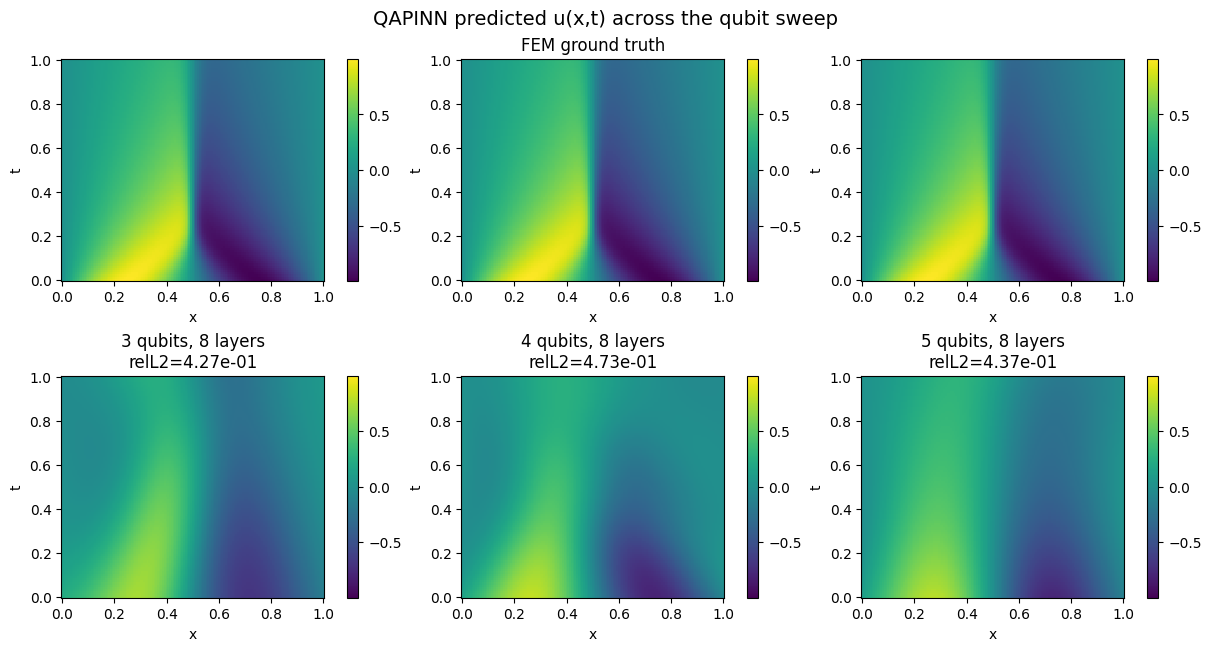

In [15]:
ncols = len(QUBIT_LIST)
fig, axes = plt.subplots(2, ncols, figsize=(4 * ncols, 6.4),
                         constrained_layout=True, squeeze=False)
vmin, vmax = U_eval.min(), U_eval.max()

# top row: FEM ground truth (repeated for visual reference)
for j in range(ncols):
    ax = axes[0][j]
    im = ax.pcolormesh(x_eval, t_eval, U_eval, shading="auto", cmap="viridis",
                       vmin=vmin, vmax=vmax)
    ax.set_title("FEM ground truth" if j == ncols // 2 else "")
    ax.set_xlabel("x"); ax.set_ylabel("t")
    fig.colorbar(im, ax=ax)

for j, nq in enumerate(QUBIT_LIST):
    ax = axes[1][j]
    r = results[nq]
    im = ax.pcolormesh(x_eval, t_eval, r["U_pred"], shading="auto",
                       cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_title(f"{nq} qubits, {r['n_layers']} layers\nrelL2={r['rel_l2']:.2e}")
    ax.set_xlabel("x"); ax.set_ylabel("t")
    fig.colorbar(im, ax=ax)
fig.suptitle("QAPINN predicted u(x,t) across the qubit sweep", fontsize=14)
plt.show()

### **10. Convergence curves**

Total-loss convergence for every configuration on a shared log axis — grouped by
qubit count. Deeper/wider circuits generally lower the achievable loss but at a
steeper per-epoch cost.

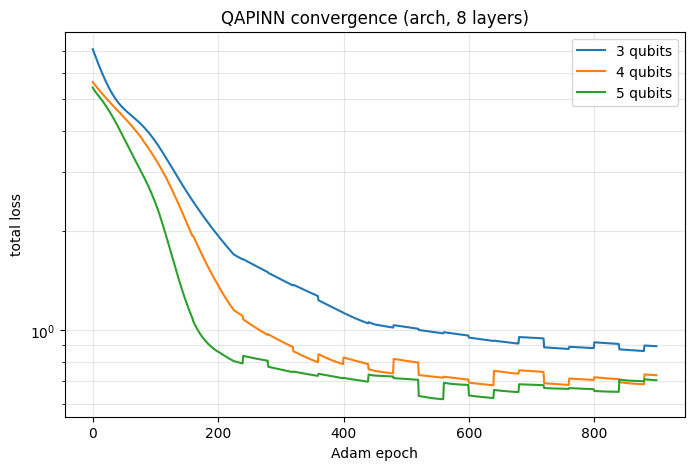

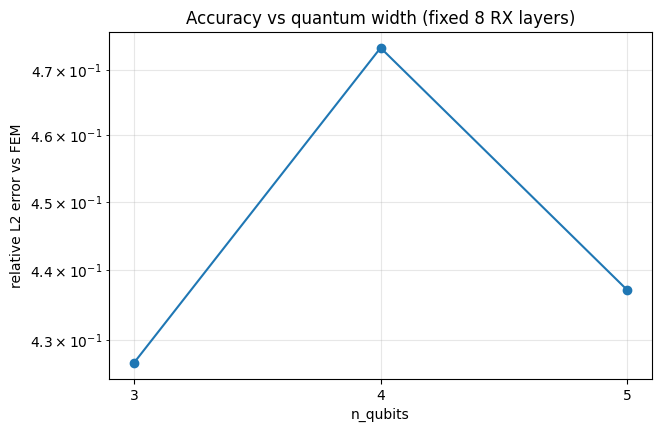

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
for nq in QUBIT_LIST:
    ax.semilogy(results[nq]["hist"]["total"], label=f"{nq} qubits")
ax.set_title(f"QAPINN convergence (arch, {N_LAYERS} layers)")
ax.set_xlabel("Adam epoch"); ax.set_ylabel("total loss")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.show()

# accuracy vs quantum width summary
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(QUBIT_LIST, [results[nq]["rel_l2"] for nq in QUBIT_LIST], "o-")
ax.set_xlabel("n_qubits"); ax.set_ylabel("relative L2 error vs FEM")
ax.set_yscale("log"); ax.set_xticks(QUBIT_LIST)
ax.set_title(f"Accuracy vs quantum width (fixed {N_LAYERS} RX layers)")
ax.grid(alpha=0.3, which="both")
plt.show()

### **11. Best configuration — detailed comparison and solution profiles**

For the most accurate configuration we compare the resolved field against FEM and
overlay solution profiles $u(\cdot,t)$ at several times to inspect how well the
quantum-assisted network captures the advecting/steepening front.

best config: 3 qubits, 8 layers | relL2=4.267e-01


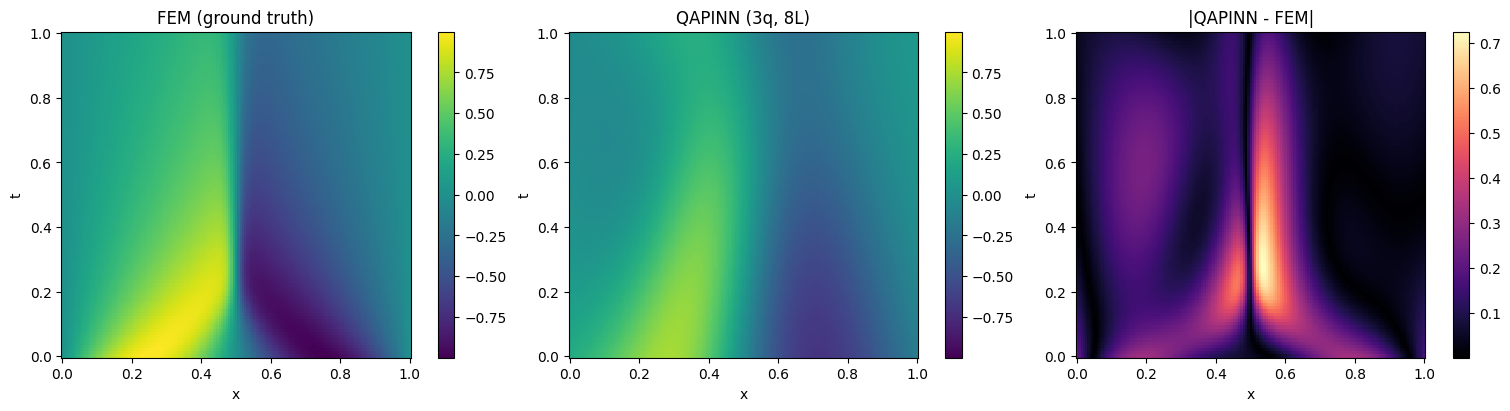

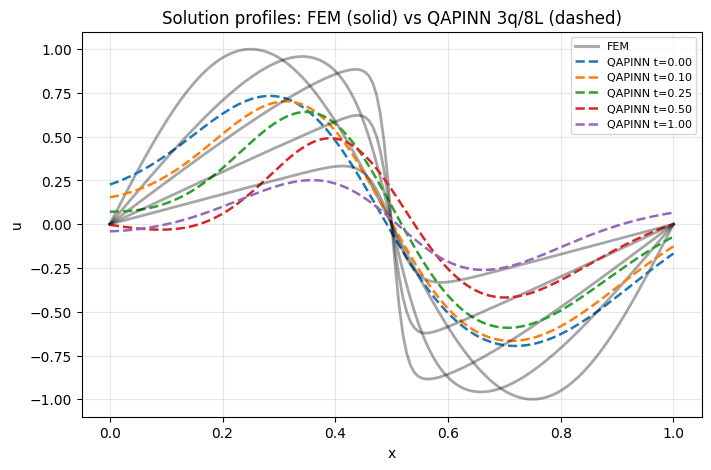

In [17]:
best_key = min(results, key=lambda k: results[k]["rel_l2"])
best_res = results[best_key]
U_pred_b = best_res["U_pred"]
print(f"best config: {best_key} qubits, {best_res['n_layers']} layers | "
      f"relL2={best_res['rel_l2']:.3e}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
vmin, vmax = U_eval.min(), U_eval.max()
for ax, field, title in [(axes[0], U_eval, "FEM (ground truth)"),
                         (axes[1], U_pred_b,
                          f"QAPINN ({best_key}q, {best_res['n_layers']}L)")]:
    im = ax.pcolormesh(x_eval, t_eval, field, shading="auto", cmap="viridis",
                       vmin=vmin, vmax=vmax)
    ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title(title); fig.colorbar(im, ax=ax)
im = axes[2].pcolormesh(x_eval, t_eval, np.abs(U_pred_b - U_eval), shading="auto",
                        cmap="magma")
axes[2].set_xlabel("x"); axes[2].set_ylabel("t"); axes[2].set_title("|QAPINN - FEM|")
fig.colorbar(im, ax=axes[2])
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for frac in [0.0, 0.1, 0.25, 0.5, 1.0]:
    k = int(frac * (len(t_eval) - 1))
    ax.plot(x_eval, U_eval[k], color="k", lw=2, alpha=0.35,
            label="FEM" if frac == 0.0 else None)
    ax.plot(x_eval, U_pred_b[k], "--", lw=1.8, label=f"QAPINN t={t_eval[k]:.2f}")
ax.set_xlabel("x"); ax.set_ylabel("u")
ax.set_title(f"Solution profiles: FEM (solid) vs QAPINN {best_key}q/{best_res['n_layers']}L (dashed)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()

### **12. Save results**

Persist the sweep summary (all loss components, accuracy, timing) and the best
hybrid model's weights.

In [18]:
os.makedirs("checkpoints", exist_ok=True)
summary = {
    "physics": {"nu": NU, "domain": [XMIN, XMAX], "T": TMAX},
    "sweep": {"qubits": QUBIT_LIST, "n_layers": N_LAYERS, "epochs": 900,
              "n_data": N_DATA_Q, "n_coll": N_COLL_Q, "n_bcic": N_BCIC_Q, "lr": LR},
    "results": [
        {"n_qubits": nq, "n_layers": results[nq]["n_layers"],
         "n_params": results[nq]["n_params"],
         "final_total": results[nq]["hist"]["total"][-1],
         "L_data": results[nq]["final"][0], "L_pde": results[nq]["final"][1],
         "L_ic": results[nq]["final"][2],   "L_bc": results[nq]["final"][3],
         "rel_l2_vs_fem": results[nq]["rel_l2"],
         "train_time_s": results[nq]["train_time"]}
        for nq in QUBIT_LIST
    ],
    "best": {"n_qubits": best_key, "n_layers": best_res["n_layers"],
             "rel_l2_vs_fem": best_res["rel_l2"]},
}
with open(os.path.join("checkpoints", "qapinn_sweep_results.json"), "w") as fh:
    json.dump(summary, fh, indent=2)

for nq in QUBIT_LIST:

    res = results[nq]

    checkpoint = {
        "state_dict": res["model"].state_dict(),

        "architecture": {
            "model": "QAPINN",
            "n_qubits": nq,
            "n_layers": res["n_layers"],
            "n_parameters": res["n_params"],
        },

        "physics": {
            "nu": NU,
            "domain": [XMIN, XMAX],
            "T": TMAX,
        },

        "training": {
            "epochs": 900,
            "learning_rate": LR,
            "train_time_s": res["train_time"],
        },

        "metrics": {
            "relative_l2": res["rel_l2"],
            "final_total_loss": res["hist"]["total"][-1],
            "loss_data": res["final"][0],
            "loss_pde": res["final"][1],
            "loss_ic": res["final"][2],
            "loss_bc": res["final"][3],
        },

        # Save complete history for XAI analysis
        "history": res["hist"],
    }

    filename = f"checkpoints/qapinn_{nq}qubit.pt"
    torch.save(checkpoint, filename)

    print(f"Saved -> {filename}")

# ------------------------------------------------------------------
# Save BEST model separately
# ------------------------------------------------------------------
best_checkpoint = {
    "state_dict": best_res["model"].state_dict(),

    "architecture": {
        "model": "QAPINN",
        "n_qubits": best_key,
        "n_layers": best_res["n_layers"],
        "n_parameters": best_res["n_params"],
    },

    "physics": {
        "nu": NU,
        "domain": [XMIN, XMAX],
        "T": TMAX,
    },

    "training": {
        "epochs": 900,
        "learning_rate": LR,
        "train_time_s": best_res["train_time"],
    },

    "metrics": {
        "relative_l2": best_res["rel_l2"],
        "final_total_loss": best_res["hist"]["total"][-1],
        "loss_data": best_res["final"][0],
        "loss_pde": best_res["final"][1],
        "loss_ic": best_res["final"][2],
        "loss_bc": best_res["final"][3],
    },

    "history": best_res["hist"],
}

torch.save(best_checkpoint, "checkpoints/qapinn_best.pt")

print(
    f"\nBest Model Saved -> checkpoints/qapinn_best.pt "
    f"({best_key} qubits, {best_res['n_layers']} layers, "
    f"Relative L2 = {best_res['rel_l2']:.4e})"
)

Saved -> checkpoints/qapinn_3qubit.pt
Saved -> checkpoints/qapinn_4qubit.pt
Saved -> checkpoints/qapinn_5qubit.pt

Best Model Saved -> checkpoints/qapinn_best.pt (3 qubits, 8 layers, Relative L2 = 4.2672e-01)


### **13. Classical PINN vs QA-PINN comparison**




In [19]:
# --- Classical baseline architecture (mirrors Burgers_PINN.ipynb saved state_dict) ---
class ClassicalPINN(nn.Module):
    def __init__(self, layers=(2, 8, 8, 8, 8, 1)):
        super().__init__()
        seq = []
        for i in range(len(layers) - 1):
            seq.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                seq.append(nn.Tanh())
        self.net = nn.Sequential(*seq)

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

_ckpt_path = os.path.join("checkpoints", "burgers_pinn.pt")
_ckpt = torch.load(_ckpt_path, map_location=DEVICE, weights_only=False)

# infer hidden width from the checkpoint's first weight matrix (defensive)
_h = _ckpt["state_dict"]["net.0.weight"].shape[0]
classical = ClassicalPINN(layers=(2, _h, _h, _h, _h, 1)).to(DEVICE)
classical.load_state_dict(_ckpt["state_dict"])
classical.eval()
n_c_params = sum(p.numel() for p in classical.parameters())
print(f"loaded classical PINN  (hidden={_h}, params={n_c_params}) "
      f"| ckpt rel L2 vs FEM = {_ckpt['rel_l2_vs_fem']:.3e}")

loaded classical PINN  (hidden=8, params=249) | ckpt rel L2 vs FEM = 5.529e-03


In [20]:
# --- Evaluate all three predictors on the FULL FEM space-time grid ---
TARGET_TIMES = [0.25, 0.50, 0.75, 0.99]

TT_full, XX_full = np.meshgrid(t_grid, x_grid, indexing="ij")   # (nt, nx)
_xin_full = to_t(norm_x(XX_full.reshape(-1, 1)))
_tin_full = to_t(norm_t(TT_full.reshape(-1, 1)))

def _grid_predict(model, chunk=2048):
    outs = []
    with torch.no_grad():
        for i in range(0, _xin_full.shape[0], chunk):
            outs.append(model(_xin_full[i:i+chunk], _tin_full[i:i+chunk]).cpu().numpy())
    return np.concatenate(outs, axis=0).reshape(U_grid.shape)

_qa_model  = best_res["model"].eval()
U_classical = _grid_predict(classical)
U_qapinn    = _grid_predict(_qa_model)

# --- global relative L2 vs FEM ground truth ---
_rl2 = lambda P: float(np.linalg.norm(P - U_grid) / np.linalg.norm(U_grid))
print(f"global rel L2 vs FEM  |  classical={_rl2(U_classical):.3e}  "
      f"|  QA-PINN({best_key}q/{best_res['n_layers']}L)={_rl2(U_qapinn):.3e}")

global rel L2 vs FEM  |  classical=5.529e-03  |  QA-PINN(3q/8L)=4.277e-01


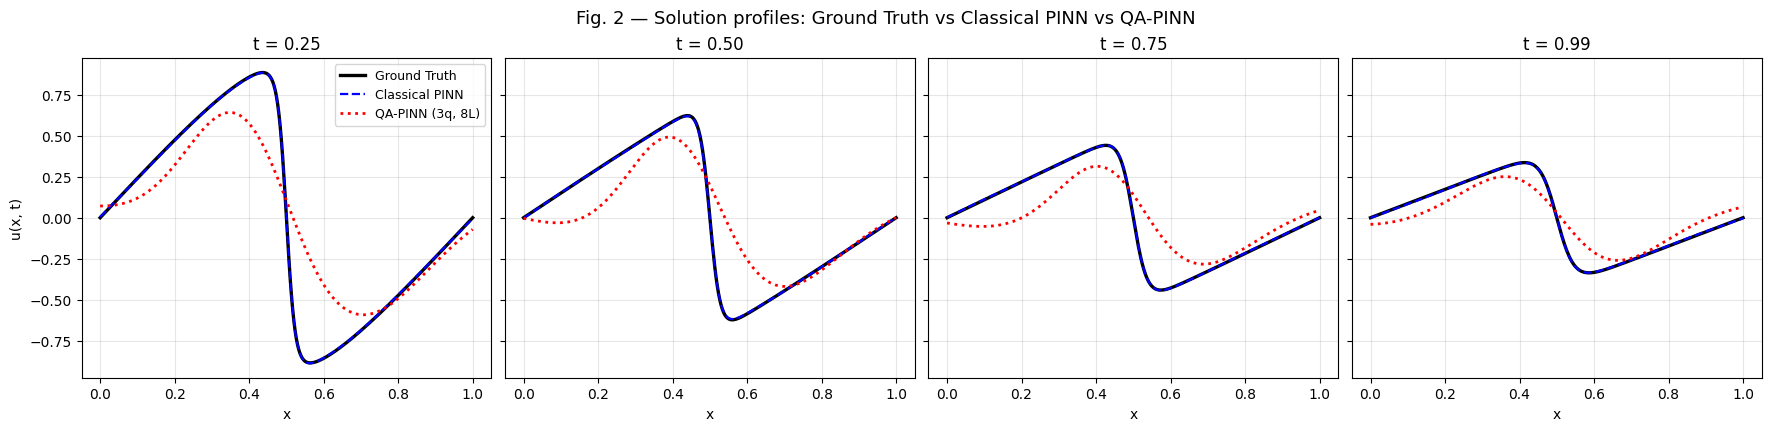

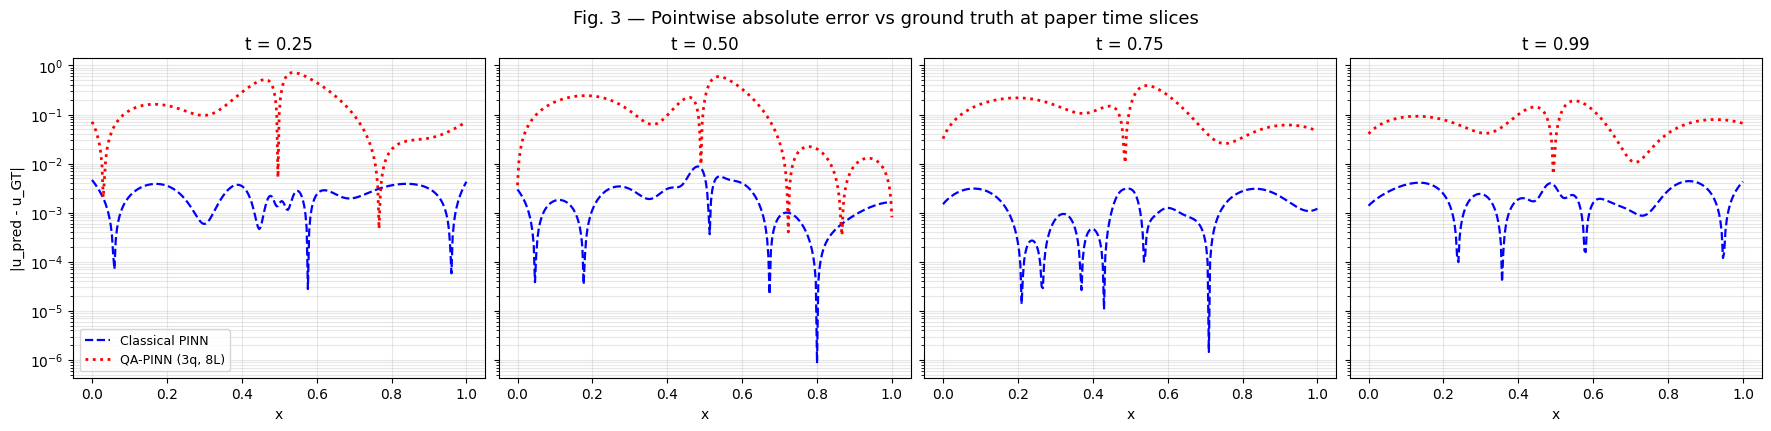

     t*    rel_L2 classical    rel_L2 QA-PINN   max|err| classical   max|err| QA-PINN
   0.25           4.402e-03         4.389e-01            4.647e-03          7.185e-01
   0.50           7.128e-03         5.128e-01            8.731e-03          5.933e-01
   0.75           6.268e-03         5.693e-01            3.102e-03          3.889e-01
   0.99           1.164e-02         3.936e-01            4.399e-03          1.910e-01


In [21]:
# --- Fig. 2 replica: solution profiles u(x, t*) at TARGET_TIMES ---
fig, axes = plt.subplots(1, len(TARGET_TIMES), figsize=(4.4 * len(TARGET_TIMES), 4.2),
                         constrained_layout=True, sharey=True)
for ax, t_star in zip(axes, TARGET_TIMES):
    k = int(np.argmin(np.abs(t_grid - t_star)))
    ax.plot(x_grid, U_grid[k],      "k-",  lw=2.4, label="Ground Truth")
    ax.plot(x_grid, U_classical[k], "b--", lw=1.6, label="Classical PINN")
    ax.plot(x_grid, U_qapinn[k],    "r:",  lw=2.0,
            label=f"QA-PINN ({best_key}q, {best_res['n_layers']}L)")
    ax.set_title(f"t = {t_grid[k]:.2f}")
    ax.set_xlabel("x"); ax.grid(alpha=0.3)
axes[0].set_ylabel("u(x, t)")
axes[0].legend(loc="best", fontsize=9)
fig.suptitle("Fig. 2 — Solution profiles: Ground Truth vs Classical PINN vs QA-PINN",
             fontsize=13)
plt.show()

# --- Fig. 3 replica: pointwise absolute error at TARGET_TIMES ---
fig, axes = plt.subplots(1, len(TARGET_TIMES), figsize=(4.4 * len(TARGET_TIMES), 4.2),
                         constrained_layout=True, sharey=True)
for ax, t_star in zip(axes, TARGET_TIMES):
    k = int(np.argmin(np.abs(t_grid - t_star)))
    ax.semilogy(x_grid, np.abs(U_classical[k] - U_grid[k]) + 1e-16,
                "b--", lw=1.6, label="Classical PINN")
    ax.semilogy(x_grid, np.abs(U_qapinn[k]    - U_grid[k]) + 1e-16,
                "r:",  lw=2.0, label=f"QA-PINN ({best_key}q, {best_res['n_layers']}L)")
    ax.set_title(f"t = {t_grid[k]:.2f}")
    ax.set_xlabel("x"); ax.grid(alpha=0.3, which="both")
axes[0].set_ylabel("|u_pred - u_GT|")
axes[0].legend(loc="best", fontsize=9)
fig.suptitle("Fig. 3 — Pointwise absolute error vs ground truth at paper time slices",
             fontsize=13)
plt.show()

# --- summary table at the four target times ---
print(f"{'t*':>7}  {'rel_L2 classical':>18}  {'rel_L2 QA-PINN':>16}  "
      f"{'max|err| classical':>19}  {'max|err| QA-PINN':>17}")
for t_star in TARGET_TIMES:
    k = int(np.argmin(np.abs(t_grid - t_star)))
    e_c = np.linalg.norm(U_classical[k] - U_grid[k]) / np.linalg.norm(U_grid[k])
    e_q = np.linalg.norm(U_qapinn[k]    - U_grid[k]) / np.linalg.norm(U_grid[k])
    m_c = np.abs(U_classical[k] - U_grid[k]).max()
    m_q = np.abs(U_qapinn[k]    - U_grid[k]).max()
    print(f"{t_grid[k]:>7.2f}  {e_c:>18.3e}  {e_q:>16.3e}  {m_c:>19.3e}  {m_q:>17.3e}")

### 13a. XAI hook — dump intermediate representations

Sanity-check the `forward(..., return_features=True)` hook: run the best QA-PINN
over the FEM grid, collect the encoder projection, quantum probability vectors
and classical hidden-layer states, and persist them to
`checkpoints/qapinn_features.npz` so an external XAI notebook can load them for
PCA / t-SNE / KDE analyses without retraining.

In [22]:
# --- Collect intermediate representations from the best QA-PINN ---
def collect_features(model, chunk=1024):
    buckets = {"encoder_pre": [], "encoder_angles": [], "quantum_probs": [],
               "decoder_hidden": [], "output": []}
    model.eval()
    with torch.no_grad():
        for i in range(0, _xin_full.shape[0], chunk):
            _, feats = model(_xin_full[i:i+chunk], _tin_full[i:i+chunk],
                             return_features=True)
            for k, v in feats.items():
                buckets[k].append(v.cpu().numpy())
    return {k: np.concatenate(v, axis=0) for k, v in buckets.items()}

_features = collect_features(_qa_model)
print("intermediate representation shapes:")
for k, v in _features.items():
    print(f"  {k:<16}  shape={v.shape}   dtype={v.dtype}")

# --- Persist for downstream XAI analyses ---
feat_path = os.path.join("checkpoints", "qapinn_features.npz")
np.savez_compressed(
    feat_path,
    x_grid=x_grid, t_grid=t_grid, U_grid=U_grid, U_qapinn=U_qapinn,
    n_qubits=np.array(best_key), n_layers=np.array(best_res["n_layers"]),
    **_features,
)
print(f"\nsaved -> {feat_path}  ({os.path.getsize(feat_path)/1024:.1f} KB)")
print("Load in an XAI notebook via:\n"
      "  d = np.load('checkpoints/qapinn_features.npz')\n"
      "  probs = d['quantum_probs']; hidden = d['decoder_hidden']")

intermediate representation shapes:
  encoder_pre       shape=(150801, 3)   dtype=float32
  encoder_angles    shape=(150801, 3)   dtype=float32
  quantum_probs     shape=(150801, 8)   dtype=float32
  decoder_hidden    shape=(150801, 4)   dtype=float32
  output            shape=(150801, 1)   dtype=float32

saved -> checkpoints/qapinn_features.npz  (11595.8 KB)
Load in an XAI notebook via:
  d = np.load('checkpoints/qapinn_features.npz')
  probs = d['quantum_probs']; hidden = d['decoder_hidden']


## Notes & interpretation

- **Hybrid autodiff works end-to-end.** Because the QNode uses
  `diff_method="backprop"` on `default.qubit`, PyTorch differentiates through the
  simulated circuit and forms the second-order residual $u_{xx}$, updating the
  quantum rotation angles jointly with the classical encoder/decoder weights.
- **Capacity vs cost.** More qubits ($2^n$ probability features) and more
  variational layers increase expressivity, but simulation cost grows quickly with
  qubit count — the 8-qubit runs dominate the sweep wall-clock. The accuracy-vs-
  capacity plot (§10) shows whether the extra capacity actually buys lower PDE
  error on this problem.
- **Comparison to the classical baseline.** The classical MLP PINN reaches
  rel $L^2 \approx 5\times10^{-3}$ with far more optimizer iterations. This
  notebook's short quantum-simulated sweep is meant to characterize the *hybrid*
  architecture's behavior, not to beat the classical model — increase
  `QAPINN_EPOCHS` (and the point counts) to push the accuracy of a chosen config.
- **Reproducibility knobs.** All sweep sizes are env-overridable
  (`QAPINN_QUBITS`, `QAPINN_LAYERS`, `QAPINN_EPOCHS`, `QAPINN_NDATA`,
  `QAPINN_NCOLL`, `QAPINN_NBCIC`, `QAPINN_LR`).